# CNN for Emotion Detection using FER 2013 Dataset
The purpose of this project is to create a CNN model (selected because it is lightweight enough to deploy on a raspberry pi) that can detect emotions from images.

For training, I am utilizing the FER 2013 Dataset which is a collection of 35,887 images that 48 × 48 grayscale images that fall into 1 of 7 emotions.

When deployed on the raspberry pi, this model will be used to detect the user's emotion which will then trigger an LED display to play a corresponding animation to mimic the emotion back. Because of this, I have elected to trim down the dataset to only 4 emotions: happy, sad, angry, and neutral.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!cp -r /content/drive/MyDrive/fer2013 /content/fer2013_local

In [3]:
# Convert Image Files into Tesnor
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [6]:
# Import data with folder names as labels
train_data = datasets.ImageFolder(
    root="/content/fer2013_local/train",
    transform=transform
)

test_data = datasets.ImageFolder(
    root="/content/fer2013_local/test",
    transform=transform
)

In [137]:
# Create data loader
train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory = True
)

The CNN model consists of 3 sequential layers that each have the following structure:
1) Conv2d -- This layer consists of a 3x3 convolution kernel that slides across the image. At each step, the dot product between the weights of the kernel and the weights of the image is calculated. These dot products each yield a single value for that specific 3x3 portion of the image which can then be combined to form a 2 dimensional feature map that often identifies features such as edges
2) BatchNorm2d -- This layer normalizes inputs to ensure stability in training and helps speed up the process
3) ReLU -- This layer performs the calculation of max(0,x) to each of the values in the input layer. This is a computationally quick way to ensure values are non-negative (ensures sparsity) and non-linear (allows for complexity)
4) MaxPool2d -- Max Pooling is a type of downsampling that takes the highest value from each sample of the feature map which ensures that the most important features are kept while unimportant ones are discarded

In [138]:
# Define CNN Model
class CNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [139]:
# Define model
model = CNN().to(device)

In [140]:
# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4)

scaler = torch.amp.GradScaler("cuda")

The training loop has a maximum of 50 epochs, but I implemented early stopping to speed up training time when it seems clear that the model will likley not improve any further

In [141]:
import time
start_time = time.time()

torch.manual_seed(13)

epochs = 50
train_losses = []
test_losses = []
train_correct = []
test_correct = []

patience = 10
best_val_loss = float("inf")
epochs_no_improve = 0

for epoch in range(epochs):
    trn_corr = 0
    tst_corr = 0
    running_train_loss = 0.0
    running_test_loss = 0.0
    b = 0

    # -------- TRAIN --------
    model.train()
    for X_train, y_train in train_loader:
        X_train = X_train.to(device, non_blocking=True)
        y_train = y_train.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            y_pred = model(X_train)
            loss = criterion(y_pred, y_train)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item() * X_train.size(0)
        trn_corr += (y_pred.argmax(dim=1) == y_train).sum().item()

    train_loss = running_train_loss / len(train_loader.dataset)
    train_acc = trn_corr / len(train_loader.dataset)

    train_losses.append(train_loss)
    train_correct.append(train_acc)

    # -------- VALIDATION / TEST --------
    model.eval()
    with torch.no_grad():
        for X_test, y_test in test_loader:
            X_test = X_test.to(device, non_blocking=True)
            y_test = y_test.to(device, non_blocking=True)

            y_val = model(X_test)
            loss = criterion(y_val, y_test)

            running_test_loss += loss.item() * X_test.size(0)
            tst_corr += (y_val.argmax(dim=1) == y_test).sum().item()

    val_loss = running_test_loss / len(test_loader.dataset)
    val_acc = tst_corr / len(test_loader.dataset)

    test_losses.append(val_loss)
    test_correct.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
        f"Total Time: {(time.time()-start_time)/60:.2f} minutes"
    )

    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break

total = time.time() - start_time
print(f"Training took: {total/60:.2f} minutes")

Epoch 1/50 | Train Loss: 1.2643, Acc: 0.4234 | Val Loss: 1.1575, Acc: 0.5035 | Total Time: 0.18 minutes
Epoch 2/50 | Train Loss: 1.1246, Acc: 0.5126 | Val Loss: 1.0771, Acc: 0.5363 | Total Time: 0.35 minutes
Epoch 3/50 | Train Loss: 1.0410, Acc: 0.5552 | Val Loss: 1.0122, Acc: 0.5693 | Total Time: 0.51 minutes
Epoch 4/50 | Train Loss: 0.9779, Acc: 0.5853 | Val Loss: 0.9891, Acc: 0.5764 | Total Time: 0.68 minutes
Epoch 5/50 | Train Loss: 0.9337, Acc: 0.6119 | Val Loss: 0.9631, Acc: 0.5894 | Total Time: 0.85 minutes
Epoch 6/50 | Train Loss: 0.9006, Acc: 0.6267 | Val Loss: 0.9258, Acc: 0.6067 | Total Time: 1.03 minutes
Epoch 7/50 | Train Loss: 0.8548, Acc: 0.6486 | Val Loss: 0.9258, Acc: 0.6109 | Total Time: 1.19 minutes
Epoch 8/50 | Train Loss: 0.8204, Acc: 0.6715 | Val Loss: 0.9172, Acc: 0.6076 | Total Time: 1.36 minutes
Epoch 9/50 | Train Loss: 0.7859, Acc: 0.6864 | Val Loss: 0.9177, Acc: 0.6151 | Total Time: 1.54 minutes
Epoch 10/50 | Train Loss: 0.7482, Acc: 0.7026 | Val Loss: 0.9374

In [142]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

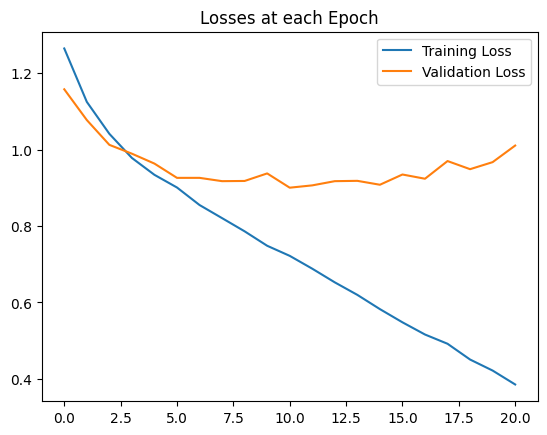

In [143]:
# Graph the loss at each epoch
plt.plot(train_losses, label = "Training Loss")
plt.plot(test_losses, label = "Validation Loss")
plt.title("Losses at each Epoch")
plt.legend()

As expected, the training loss decreased over the course of the epochs as the model became better and better at performing on the seen data.

However, the more important metric is the valuation loss as it shows the model's performance on unseen data and givens a better idea on the model ability to be useful once deployed in a non-training environment.

The graph shows an initial decrease that eventually plateaus and then starts to increase again. This is due to the model starting to overfit to training data. To counteract this, I stored the best performing model so that I could reload the older model after training was complete.

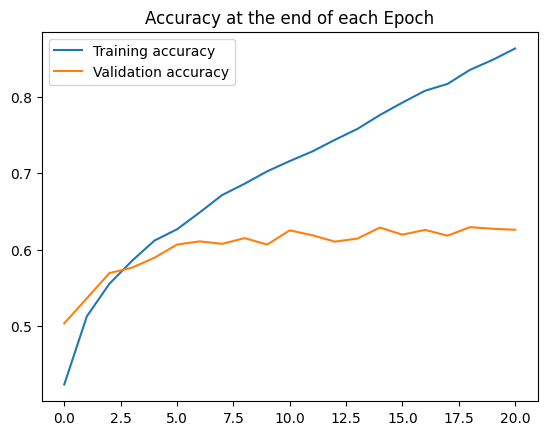

In [147]:
# graph the accuracy at the end of each epoch
plt.plot([t for t in train_correct], label = "Training accuracy")
plt.plot([t for t in test_correct], label = "Validation accuracy")
plt.title("Accuracy at the end of each Epoch")
plt.legend()

Once again, as expected the training accuracy greatly increases over the course of the training; however, the validation accuracy plateaus around 62% for most of the training. The failure to improve further is reflected in the loss function also increasing beyond around epoch 10

In [145]:
# evaluate model
misclassified = []
max_misclassified = 5
all_labels = []
all_preds = []

model.eval()

with torch.no_grad():
  for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        inputs_np = inputs.cpu().numpy()
        labels_np = labels.cpu().numpy()
        preds_np = preds.cpu().numpy()

        all_labels.extend(labels_np)
        all_preds.extend(preds_np)

        for i in range(len(labels_np)):
            if preds_np[i] != labels_np[i] and len(misclassified) < max_misclassified:
                misclassified.append({
                    'input': inputs_np[i],
                    'true_label': labels_np[i],
                    'pred_label': preds_np[i]
                })



In [146]:
# calculate accuracy
accuracy = accuracy_score(y_true=all_labels, y_pred=all_preds)
print(f'Overall accuracy: {accuracy:.4f}')

Overall accuracy: 0.6253


In [148]:
# classification report
emotions = ['angry', 'happy', 'sad', 'neutral']
print(classification_report(y_true=all_labels, y_pred=all_preds, target_names=emotions))

              precision    recall  f1-score   support

       angry       0.67      0.38      0.49       958
       happy       0.81      0.77      0.79      1774
         sad       0.51      0.67      0.58      1233
     neutral       0.51      0.57      0.54      1247

    accuracy                           0.63      5212
   macro avg       0.63      0.60      0.60      5212
weighted avg       0.64      0.63      0.62      5212



Based on the classification report, the model seemed to struggle thee most with angry (which may be a product of it being the emotion with the least number of examples).

The model performed the best with happy emotions. 81% of the images that the model classified as happy were actually happy, and 77% of the images that were actually were correctly identified by the model. One possible explanation of this is that happy is the most disimilar from the other emotions as aspects such as smiling are only present for the happy emotion.

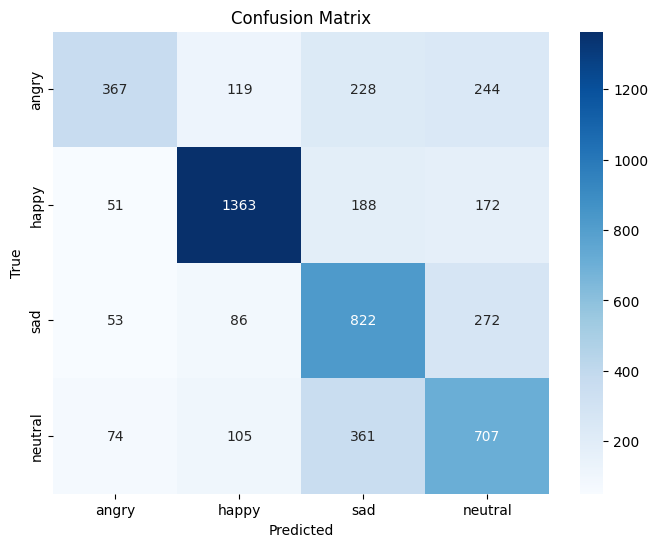

In [149]:
# confusion matrix
cm = confusion_matrix(y_true=all_labels, y_pred=all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotions, yticklabels=emotions)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

The most common bi-directional confusion seems to be between sad and neutral. This kind of makes intuitive sense as neutral doesn't really have a specific associated facial expression, and features of sad (such as lack of smiling) could in some cases also be interpreted as just neutral.

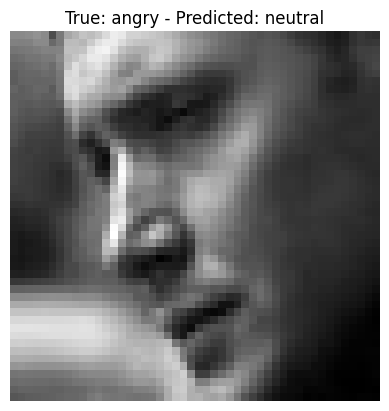

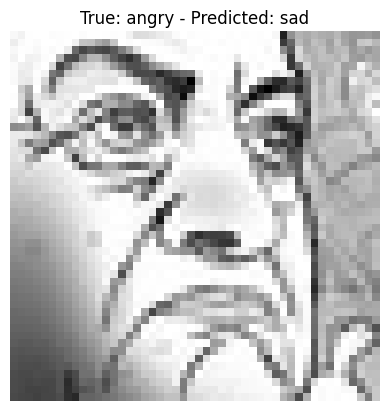

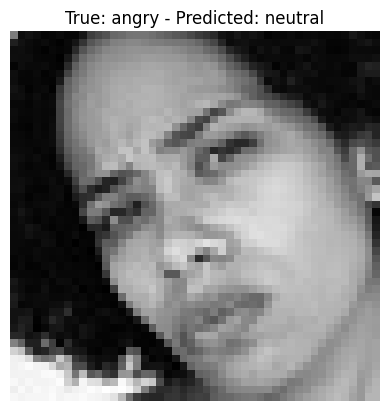

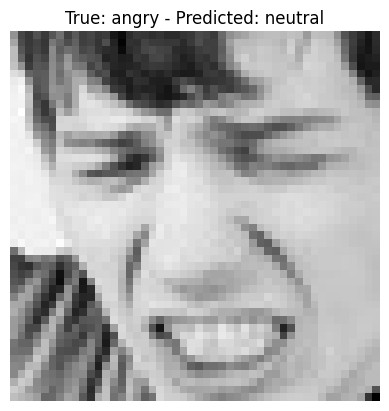

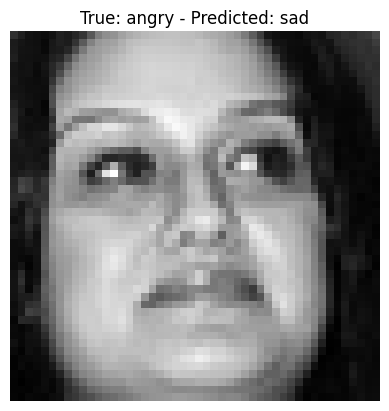

In [150]:
# example misclassifications
def denormalize(img_tensor):
  img = img_tensor*0.5 + 0.5
  img = img.squeeze()
  img = img.numpy()
  return img

def plot_misclassified(misclassified, class_names):
    for i, sample in enumerate(misclassified):
        img = sample['input']
        # Convert back to torch tensor for denormalize function if needed
        if not isinstance(img, torch.Tensor):
            img = torch.from_numpy(img)

        img = denormalize(img)
        true_class = class_names[sample['true_label']]
        pred_class = class_names[sample['pred_label']]

        plt.figure()
        plt.imshow(img, cmap='gray')
        plt.title(f"True: {true_class} - Predicted: {pred_class}")
        plt.axis('off')
        plt.show()

plot_misclassified(misclassified, emotions)

All of these misclassified photos are supposedly of anger, but they don't really look like anger. This is a good sign as it means that my model isn't failing at obvious anger images pureple because anger is least represented

### Note --
Other models were tested varying number of layers (3 or 4), learning rate (0.01, 0.001, or 0.0001), and batch size (32, 64, or 128), but this model was the best performing based on validation loss, so it was selected as the final model.

In [152]:
# Export Model Weights
from google.colab import files

torch.save(model.state_dict(), 'cnn_weights.pth')

files.download('cnn_weights.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>